In [1]:
import torch
import numpy as np
from matplotlib import pyplot as plt

import utilities as utils
import care

# Training a global operator on synthetic data

### Stationary synthetic dataset

In the synthetic case, the stationary time series include pure 10Hz signals, 24Hz signals, as well as their sum. This is displayed below.


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



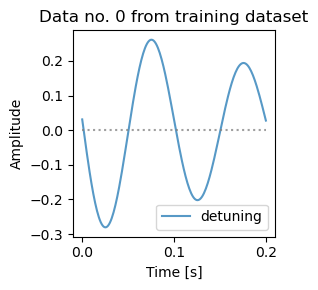

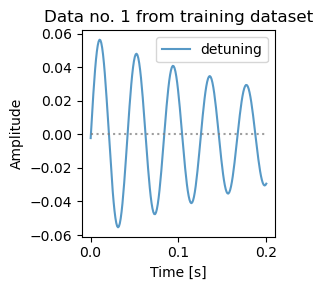

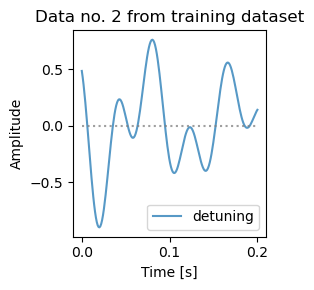

In [2]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir     = 'data/train_sim_g'
timeseries_len  = 200
timestep        = 0.001
x_dims_n        = 1
x_len           = 200
utils.disp_dataset(dataset_dir, timeseries_len, timestep)

### Model instantiation

The model is instantiated with 4 basis functions: a sine and a cosine, as well as 2 data-driven functions. We set parameter $\tau=40$, as this value allows the DMD-like global operator to consistently identify two distinct complex eigenvalue pairs corresponding to the fast and slow oscillatory modes.

In [3]:
# --!--------------------------------------------------------------------------
# --! instantiate a model

# --! ensure reproducible results
seed = 5
torch.manual_seed(seed)

cfg = care.config(

    timeseries_dims_n     = x_dims_n,
    timeseries_sz         = x_len,
    timeseries_timestep   = timestep,

    funs={
        'sin'   : 2,
        'cos'   : 2,
        'data1' : 1,
        'data2' : 1,
    },
    fun_params_kern_sz    = 40,

    fit_weight_lin_global = 1.,
    fit_weight_lin_local  = 0.
)

model = care.detune(cfg)

### Global operator training

In [4]:
# --!--------------------------------------------------------------------------
# --! train the global operator

train_params = {
    'dataset_dir'   : dataset_dir,
    'timeseries_sz' : timeseries_len,
    'train_files_n' : 7,
    'batch_sz'      : 128,
    'epochs_n'      : 100,
    'x_sz'          : x_len,
    'is_verbose'    : True,
    'is_global'     : True,
    'learn_rate'    : 1e-3,
    'weight_decay'  : 1e-8,
    'alpha'         : 1.0
}

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


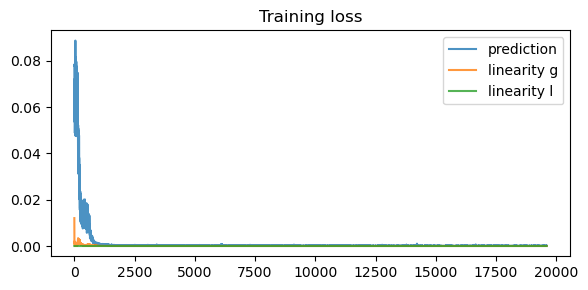

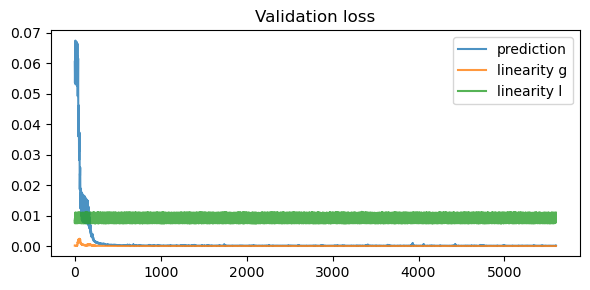

In [5]:
# --!--------------------------------------------------------------------------
# --! display training and validation statistics

with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [6]:
# --!--------------------------------------------------------------------------
# --! save a trained global model

savemod_on = True
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'models/care_sim_g.pt')

Parameter containing:
tensor([[ 0.7889, -0.0103,  0.0036,  0.1001],
        [ 0.8660, -0.3929, -0.6742, -0.0887],
        [-0.5034, -0.0661, -0.3378,  0.8845],
        [ 0.3287, -0.7923,  0.3279,  0.1410]], requires_grad=True)


# Training a local operator on synthetic data


inf >> dataset parameters:

 dataset  batches  timeseries length channels
--------  -------  ----------------- --------
   train     3500                200        1
   valid     1000                200        1
    test      500                200        1



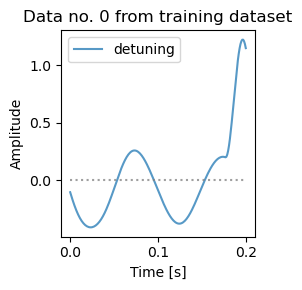

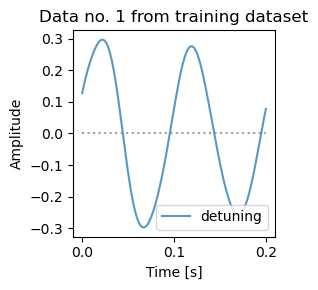

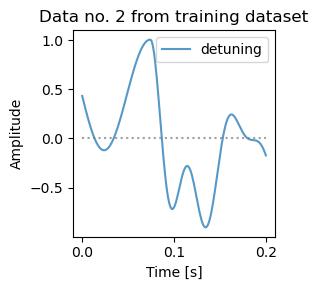

In [7]:
# --!------------------------------------------------------!
# --! display dataset metrics

dataset_dir = 'data/train_sim_l'
utils.disp_dataset(dataset_dir, timeseries_len, timestep)

### Local operator training

In [8]:
# --!--------------------------------------------------------------------------
# --! train the global operator

# --! we reuse the training parameters we defined above, but this time we
# --! update some of them, like the dataset directory, alpha, etc.
train_params['dataset_dir'] = dataset_dir
train_params['is_global']   = False
train_params['alpha']       = 0.5

outs = utils.train(model, train_params)

loss_train_pred  = outs[0]
loss_train_lin_g = outs[1]
loss_train_lin_l = outs[2]
loss_valid_pred  = outs[3]
loss_valid_lin_g = outs[4]
loss_valid_lin_l = outs[5]

inf >> Number of data files for training : 7
inf >> processing training file number 1
inf >> processing training file number 2
inf >> processing training file number 3
inf >> processing training file number 4
inf >> processing training file number 5
inf >> processing training file number 6
inf >> processing training file number 7


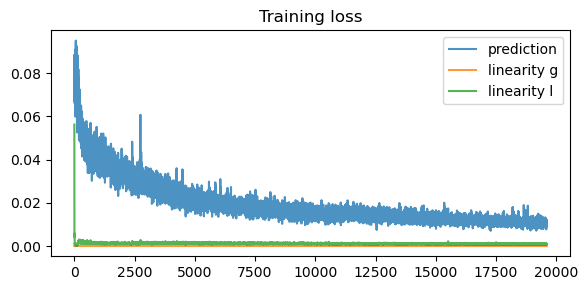

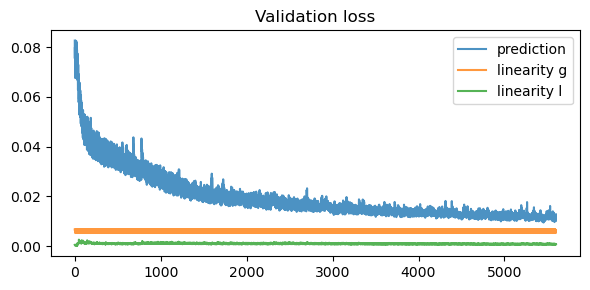

In [9]:
# --! display training statistics
with torch.no_grad():
    plt.figure(figsize=(6, 3))
    plt.title('Training loss')
    plt.plot(loss_train_pred, alpha=0.8, label='prediction')
    plt.plot(loss_train_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_train_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 3))
    plt.title('Validation loss')
    plt.plot(loss_valid_pred, alpha=0.8, label='prediction')
    plt.plot(loss_valid_lin_g, alpha=0.8, label='linearity g')
    plt.plot(loss_valid_lin_l, alpha=0.8, label='linearity l')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [10]:
# --!--------------------------------------------------------------------------
# --! save a trained local model

savemod_on = True

# --! sanity check that the global operator hasn't changed
print(model.timeseries_dyn.weight)

if savemod_on:
    torch.save(model, 'models/care_sim_l.pt')

Parameter containing:
tensor([[ 0.7889, -0.0103,  0.0036,  0.1001],
        [ 0.8660, -0.3929, -0.6742, -0.0887],
        [-0.5034, -0.0661, -0.3378,  0.8845],
        [ 0.3287, -0.7923,  0.3279,  0.1410]])


# Gathering training statistics

In [47]:
# --!---------------------------------------------!
# --! helping routines

def gather_train_stats(train_params, trains_n):

    # --! placeholders for losses
    losses_train_pred = []
    losses_valid_pred = []
    losses_test_pred  = []

    for i in range(trains_n):
        this = i + 1
        print(f'inf >> iteration number {this}')

        # --! preset the random seed
        torch.manual_seed(this)

        # --! recreate a model
        model = care.detune(cfg)

        # --! train the model
        outs = utils.train(model, train_params)
        loss_train_pred  = outs[0]
        loss_valid_pred  = outs[3]
        with torch.no_grad():
            losses_train_pred.append(loss_train_pred[-1])
            losses_valid_pred.append(loss_valid_pred[-1])

        # --! test the model
        with torch.no_grad():
            loss_test_pred = utils.test(model, train_params)
            losses_test_pred.append(np.mean(loss_test_pred))

    return losses_train_pred, losses_valid_pred, losses_test_pred

def disp_train_stats(stats, iters_n, operator: str='Global'):
    """Prints training statistics."""
    losses_train_pred = stats[0]
    losses_valid_pred = stats[1]
    losses_test_pred  = stats[2]

    train_mean = np.mean(losses_train_pred)
    valid_mean = np.mean(losses_valid_pred)
    test_mean  = np.mean(losses_test_pred)

    train_std  = np.std(losses_train_pred)
    valid_std  = np.std(losses_valid_pred)
    test_std   = np.std(losses_test_pred)

    # --! compile statistics
    stats_table = [
        (            '',          'Training',        'Validation',                               'Test'),
        ('------------',      '------------',      '------------',                 '------------------'),
        (      operator, f'{train_mean:.1e}', f'{valid_mean:.1e}',  f'{test_mean:.1e} +- {test_std:.1e}') ]

    # --! print dataset parameters
    print('')
    print(f'inf >> training statistics for {iters_n} iteration(s):')
    print('')
    for row in stats_table:
        print(f'{row[0]:>14} {row[1]:>14} {row[2]:>14} {row[3]:>20}')
    print('')

### Global operator

In [48]:
# --!------------------------------------------------------!
# --! gather statistics

stats_on = True

if stats_on:

    # --! restore parameters to the 'global' state
    train_params['dataset_dir'] = 'data/train_sim_g'
    train_params['is_global']   = True
    train_params['is_verbose']  = False
    train_params['alpha']       = 1.0

    trains_n = 30

    outs = gather_train_stats(train_params, trains_n)
    losses_train_pred = outs[0]
    losses_valid_pred = outs[1]
    losses_test_pred  = outs[2]

inf >> iteration number 1
inf >> iteration number 2
inf >> iteration number 3
inf >> iteration number 4
inf >> iteration number 5
inf >> iteration number 6
inf >> iteration number 7
inf >> iteration number 8
inf >> iteration number 9
inf >> iteration number 10
inf >> iteration number 11
inf >> iteration number 12
inf >> iteration number 13
inf >> iteration number 14
inf >> iteration number 15
inf >> iteration number 16
inf >> iteration number 17
inf >> iteration number 18
inf >> iteration number 19
inf >> iteration number 20
inf >> iteration number 21
inf >> iteration number 22
inf >> iteration number 23
inf >> iteration number 24
inf >> iteration number 25
inf >> iteration number 26
inf >> iteration number 27
inf >> iteration number 28
inf >> iteration number 29
inf >> iteration number 30


In [49]:
# --!------------------------------------------------------!
# --! display gathered statistics

if stats_on:
    with torch.no_grad():
        disp_train_stats(outs, trains_n, 'Global')


inf >> training statistics for 30 iteration(s):

                     Training     Validation                 Test
  ------------   ------------   ------------   ------------------
        Global        1.2e-04        1.3e-04   1.2e-04 +- 2.8e-05



### Local operator

In [50]:
# --!------------------------------------------------------!
# --! gather statistics

stats_on = True

if stats_on:

    # --! advance parameters to the 'local' state
    train_params['dataset_dir'] = 'data/train_sim_l'
    train_params['is_global']   = False
    train_params['is_verbose']  = False
    train_params['alpha']       = 0.5

    trains_n = 30

    outs = gather_train_stats(train_params, trains_n)

inf >> iteration number 1
inf >> iteration number 2
inf >> iteration number 3
inf >> iteration number 4
inf >> iteration number 5
inf >> iteration number 6
inf >> iteration number 7
inf >> iteration number 8
inf >> iteration number 9
inf >> iteration number 10
inf >> iteration number 11
inf >> iteration number 12
inf >> iteration number 13
inf >> iteration number 14
inf >> iteration number 15
inf >> iteration number 16
inf >> iteration number 17
inf >> iteration number 18
inf >> iteration number 19
inf >> iteration number 20
inf >> iteration number 21
inf >> iteration number 22
inf >> iteration number 23
inf >> iteration number 24
inf >> iteration number 25
inf >> iteration number 26
inf >> iteration number 27
inf >> iteration number 28
inf >> iteration number 29
inf >> iteration number 30


In [51]:
# --!------------------------------------------------------!
# --! display gathered statistics

if stats_on:
    with torch.no_grad():
        disp_train_stats(outs, trains_n, 'Local')


inf >> training statistics for 30 iteration(s):

                     Training     Validation                 Test
  ------------   ------------   ------------   ------------------
         Local        1.3e-02        1.4e-02   1.3e-02 +- 2.8e-03

